# Lab 35 — Fourier Analysis in Practice: Windows, Resolution, Uncertainty, Group Delay, Spectrograms and Intermodulation

**Companion to Chapter 2** (*Signals, Spectra and Systems*). Lab 1 covers the complex envelope and IQ sampling; this lab is a
workbench for the spectral measurements an engineer makes every day.
**Time needed:** about 90 minutes. **Difficulty:** introductory to core.

A spectrum analyzer, an SDR waterfall and an FFT in a modem all show "the spectrum", but each is an *estimate* shaped by choices:
the window, the length, the overlap, the definition of bandwidth. Get them wrong and a −60 dB spur disappears under leakage, a
tone reads 4 dB low, two signals merge, or a bandwidth is off by a factor of twenty. This lab works through those choices with the
experiments behind Chapter 2's figures (from `book/figscripts/ch02_figs.py`) and ends with the two-tone test that characterises every
amplifier's linearity.

### What you will learn
1. Choose a window: leakage, sidelobes, main-lobe width and scalloping loss; what zero padding does and does not do.
2. Measure the time–bandwidth product of pulses and see why the Gaussian minimises it.
3. Separate phase delay from group delay, and watch dispersion spread a pulse.
4. Trade time against frequency resolution in a spectrogram (STFT).
5. Measure five definitions of bandwidth on the same signal.
6. Run a two-tone test: IM3 products, the third-order intercept and its consequences.

### Prerequisites
Chapter 2 (Fourier transform, DFT, filters). Lab 1 helps but is not required.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Windows, leakage, scalloping and zero padding | yes |
| 2 | The uncertainty principle | yes |
| 3 | Phase delay, group delay and dispersion | yes |
| 4 | The spectrogram: time versus frequency resolution | yes |
| 5 | Five bandwidths of one signal | yes |
| 6 | Two-tone testing and IP3 | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sps
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=35, lab="35")
WINDOWS = {"rectangular": lambda N: np.ones(N), "Hann": np.hanning, "Blackman-Harris": sps.windows.blackmanharris, "flat-top": sps.windows.flattop}

Lab 35 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 35


## 1. Windows, leakage, scalloping and zero padding

A DFT of $N$ samples sees the signal through a window $w[n]$, so each tone appears as a copy of the window's spectrum: a main lobe
(whose width sets the resolution) and sidelobes (which leak the tone's energy across the band and can bury weak neighbours). The
rectangular window has the narrowest main lobe but sidelobes at only −13 dB; Hann −31 dB; Blackman–Harris −92 dB; flat-top is wide but
reads amplitudes accurately. A tone between two bins is read low by the **scalloping loss**: 3.9 dB for rectangular, 1.4 dB for Hann,
under 0.01 dB for flat-top. **Zero padding** interpolates the spectrum (more points on the same curve) but does not improve resolution.
Chapter 2's worked example picks Blackman–Harris and $N = 1024$ at 1 MS/s to see spurs 50 dB down within 20 kHz.

### Interactive: window, offset and padding

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

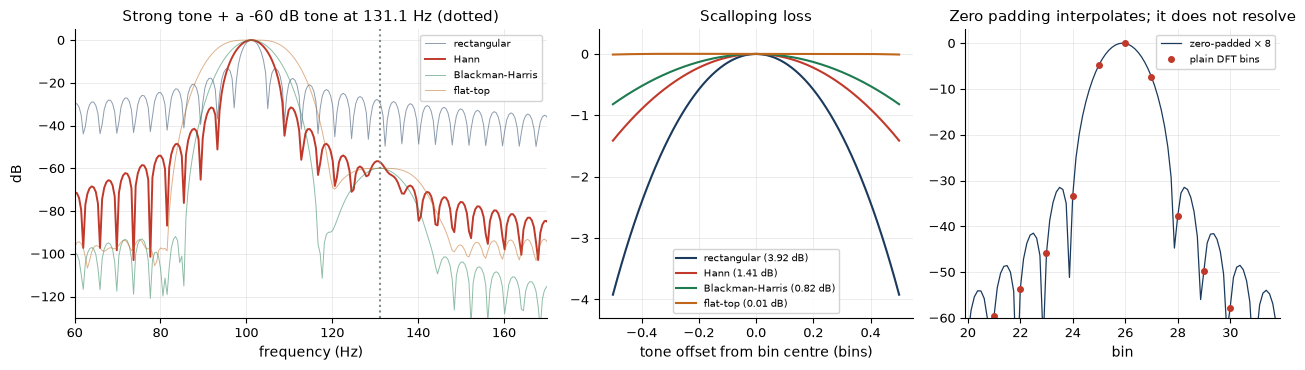

Hann,
equivalent noise bandwidth (bins),1.51
strong tone read at,-0.06 dB (true 0 dB)
Chapter 2 example: N for 1.25 kHz bins at 1 MS/s,800 → use 1024 (977 Hz bins)
… noise per bin with BH (ENBW ≈ 2 bins) at −150 dBm/Hz,-117 dBm


In [3]:
def window_demo(window="Hann", weak_db=-60.0, offset_bins=0.3, N=256, pad=8):
    fs = 1000.0
    n = np.arange(N)
    f1 = 100.0 + offset_bins * fs / N
    x = np.sin(2 * np.pi * f1 * n / fs) + 10 ** (weak_db / 20) * np.sin(2 * np.pi * 131.1 * n / fs)
    fig, ax = lk.fig((13, 3.8), 1, 3, gridspec_kw=dict(width_ratios=[1.5, 1, 1]))
    for name, wf in WINDOWS.items():
        w = wf(N)
        X = np.fft.rfft(x * w, pad * N) / np.sum(w)
        fr = np.fft.rfftfreq(pad * N, 1 / fs)
        ax[0].plot(fr, 20 * np.log10(np.abs(X) + 1e-12) + 6.02, lw=1.4 if name == window else 0.7, alpha=1 if name == window else 0.5, label=name)
    ax[0].axvline(131.1, color=lk.GRAY, ls=":"); ax[0].set_xlim(60, 170); ax[0].set_ylim(-130, 5); ax[0].set_xlabel("frequency (Hz)"); ax[0].set_ylabel("dB")
    ax[0].legend(fontsize=7.5); ax[0].set_title(f"Strong tone + a {weak_db:g} dB tone at 131.1 Hz (dotted)")
    d = np.linspace(-0.5, 0.5, 201); M = 256; m = np.arange(M)
    for name, wf in WINDOWS.items():
        w = wf(M)
        loss = [20 * np.log10(np.abs(np.sum(w * np.exp(2j * np.pi * dd * m / M))) / np.sum(w)) for dd in d]
        ax[1].plot(d, loss, label=f"{name} ({-min(loss):.2f} dB)")
    ax[1].set_ylim(-4.3, 0.4); ax[1].set_xlabel("tone offset from bin centre (bins)"); ax[1].legend(fontsize=7); ax[1].set_title("Scalloping loss")
    w = WINDOWS[window](N)
    Xc = np.abs(np.fft.fft(x * w)) / np.sum(w) * 2; Xp = np.abs(np.fft.fft(x * w, pad * N)) / np.sum(w) * 2
    ax[2].plot(np.arange(pad * N) / pad, lk.db(Xp, power=False), color=lk.NAVY, lw=0.9, label=f"zero-padded × {pad}")
    ax[2].plot(np.arange(N), lk.db(Xc, power=False), "o", color=lk.RED, ms=4, label="plain DFT bins")
    k0 = f1 / fs * N
    ax[2].set_xlim(k0 - 6, k0 + 6); ax[2].set_ylim(-60, 3); ax[2].set_xlabel("bin"); ax[2].legend(fontsize=7.5)
    ax[2].set_title("Zero padding interpolates; it does not resolve")
    lk.show(fig)
    enbw = N * np.sum(w ** 2) / np.sum(w) ** 2
    lk.table([["equivalent noise bandwidth (bins)", f"{enbw:.2f}"], ["strong tone read at", f"{lk.db(Xc.max(), power=False):.2f} dB (true 0 dB)"],
              ["Chapter 2 example: N for 1.25 kHz bins at 1 MS/s", f"{1e6 / 1250:.0f} → use 1024 (977 Hz bins)"],
              ["… noise per bin with BH (ENBW ≈ 2 bins) at −150 dBm/Hz", f"{-150 + 10 * np.log10(2.0 * 977):.0f} dBm"]], [window, ""])

lk.interact(window_demo, window=lk.choice(list(WINDOWS), "Hann", "window"), weak_db=lk.slider(-60, -100, -20, 5, "weak tone (dB)"),
            offset_bins=lk.slider(0.3, 0.0, 0.5, 0.05, "strong tone offset from a bin (bins)"), N=lk.choice([64, 256, 1024], 256, "N"),
            pad=lk.choice([1, 2, 8, 32], 8, "zero-padding factor"))

**What you should see.** With the rectangular window the −60 dB tone 30 Hz away is buried under the strong tone's sidelobes; Hann
shows it; Blackman–Harris shows it with 30 dB to spare. The scalloping panel reproduces the chapter: 3.92 dB rectangular, 1.41 dB
Hann, 0.82 dB Blackman–Harris, almost zero flat-top. Zero padding draws the window's main lobe smoothly through the plain DFT bins
without separating anything new. The table gives Chapter 2's FFT choice: about 800 → 1024 points and −117 dBm of noise per bin.

### Try it yourself 1.1
What is the bin spacing (Hz) of a 4096-point FFT at 30.72 MS/s (an LTE 20 MHz sample rate)?

In [5]:
answer_1_1 = None
lk.check("1.1 bin spacing (Hz)", answer_1_1, 30.72e6 / 4096, atol=1)

[TODO] 1.1 bin spacing (Hz): not attempted yet: replace the None with your answer

## 2. The uncertainty principle

A pulse cannot be both short and narrowband: with RMS duration $\sigma_t$ and RMS bandwidth $\sigma_f$ (of $|x|^2$ and $|X|^2$),
$\sigma_t\sigma_f \ge 1/(4\pi) \approx 0.0796$, with equality only for the Gaussian. The rectangle is short but its sinc spectrum decays
so slowly that its $\sigma_f$ is infinite. This is why GMSK, Bluetooth and many radars use Gaussian shaping.

### Interactive: pulse width

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

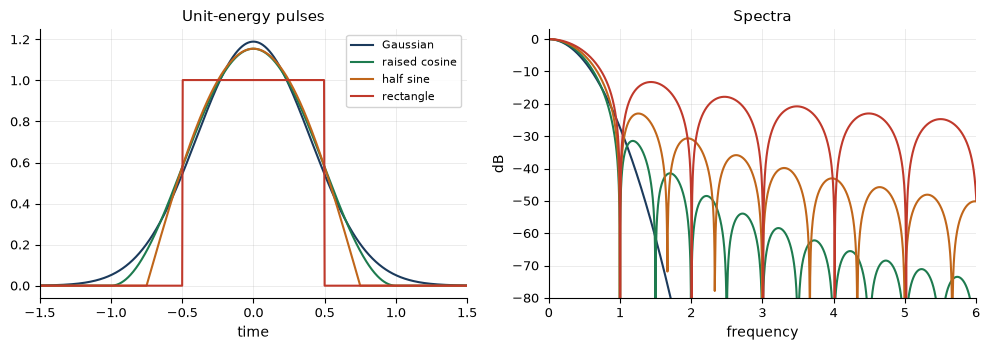

pulse,σ_t,σ_f,σ_t·σ_f,× 4π (≥ 1)
Gaussian,0.2821,0.2821,0.0796,1.0000
raised cosine,0.2829,0.2887,0.0817,1.0262
half sine,0.2711,0.3336,0.0904,1.1366
rectangle,0.2875,4.2485,1.2216,15.3515


In [7]:
def rms_widths(t, x, f, X):
    pt = np.abs(x) ** 2; pt /= pt.sum(); pf = np.abs(X) ** 2; pf /= pf.sum()
    mt, mf = np.sum(t * pt), np.sum(f * pf)
    return np.sqrt(np.sum((t - mt) ** 2 * pt)), np.sqrt(np.sum((f - mf) ** 2 * pf))

def uncert_demo(width=1.0):
    N = 2 ** 16; dt = 1 / 256; t = (np.arange(N) - N // 2) * dt
    f = np.fft.fftshift(np.fft.fftfreq(N, dt))
    pulses = [("Gaussian", lambda tt: np.exp(-np.pi * tt ** 2 / width ** 2), lk.NAVY),
              ("raised cosine", lambda tt: np.where(np.abs(tt) < width, 0.5 * (1 + np.cos(np.pi * tt / width)), 0), lk.GREEN),
              ("half sine", lambda tt: np.where(np.abs(tt) < 0.75 * width, np.cos(np.pi * tt / (1.5 * width)), 0), lk.ORANGE),
              ("rectangle", lambda tt: np.where(np.abs(tt) < 0.5 * width, 1.0, 0), lk.RED)]
    fig, ax = lk.fig("row2", 1, 2)
    rows = []
    for name, fn, col in pulses:
        x = fn(t); x = x / np.sqrt(np.sum(x ** 2) * dt)
        X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x))) * dt
        st, sf = rms_widths(t, x, f, X)
        rows.append([name, st, sf, st * sf, st * sf * 4 * np.pi])
        ax[0].plot(t, x, color=col, label=name); ax[1].plot(f, lk.db(np.abs(X) / np.abs(X).max(), power=False), color=col)
    ax[0].set_xlim(-1.5 * width, 1.5 * width); ax[0].legend(fontsize=8); ax[0].set_xlabel("time"); ax[0].set_title("Unit-energy pulses")
    ax[1].set_xlim(0, 6 / width); ax[1].set_ylim(-80, 3); ax[1].set_xlabel("frequency"); ax[1].set_ylabel("dB"); ax[1].set_title("Spectra")
    lk.show(fig)
    lk.table(rows, ["pulse", "σ_t", "σ_f", "σ_t·σ_f", "× 4π (≥ 1)"], fmt=".4f", title="Time–bandwidth products (rectangle's σ_f is limited only by the sample rate)")

lk.interact(uncert_demo, width=lk.slider(1.0, 0.25, 2.0, 0.05, "pulse width"))

**What you should see.** The Gaussian's product is $1/4\pi = 0.0796$ to four digits ($\times 4\pi = 1.000$), the raised cosine and half
sine are a little above it, and the rectangle's is large and grows with the sample rate (its true $\sigma_f$ is infinite). Change the
width: $\sigma_t$ and $\sigma_f$ trade exactly, and the product does not move.

## 3. Phase delay, group delay and dispersion

A filter with phase $\phi(f)$ delays a carrier by the **phase delay** $\tau_p = -\phi(f_c)/(2\pi f_c)$ and the envelope riding on it by the
**group delay** $\tau_g = -\frac{1}{2\pi}\frac{d\phi}{df}$. They need not be equal, or even have the same sign: Chapter 2's GPS example, the
ionosphere delays the code (group) by $40.3\,\mathrm{TEC}/f^2$ metres and advances the carrier phase by the same amount, 1.62 m on L1 and
2.67 m on L2 for 10 TEC units. If the group delay varies with frequency (a quadratic phase), different parts of the spectrum arrive at
different times and a short pulse spreads: **dispersion**.

### Interactive: delays and dispersion

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

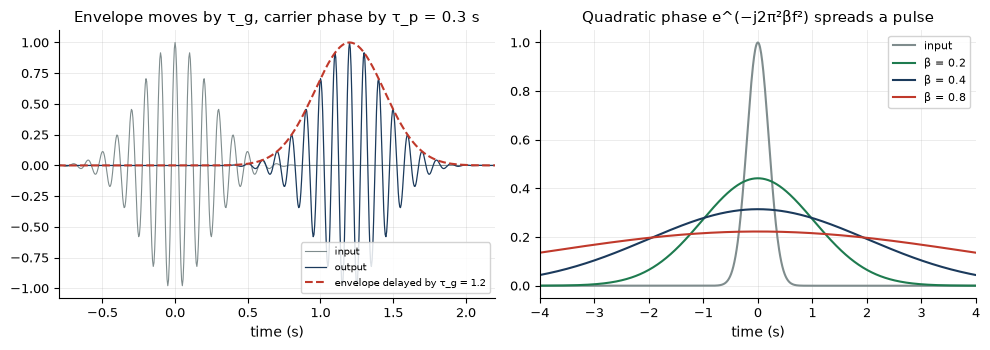

"ionosphere, 10 TEC units",
GPS L1 1575.42 MHz: group delay / phase advance,1.62 m
GPS L2 1227.6 MHz,2.67 m
ratio L2/L1,1.647
dual-frequency (iono-free) combination removes,the 1/f² term exactly


In [9]:
def gd_demo(tg=1.2, tp=0.3, beta=0.4, tec_units=10.0):
    N = 2 ** 15; fs = 200.0; t = (np.arange(N) - N // 4) / fs; f = np.fft.fftfreq(N, 1 / fs); fc = 10.0
    env = np.exp(-np.pi * (t / 0.6) ** 2); x = env * np.cos(2 * np.pi * fc * t)
    ph = 2 * np.pi * (fc * tp + (np.abs(f) - fc) * tg) * np.sign(f)
    y = np.real(np.fft.ifft(np.fft.fft(x) * np.exp(-1j * ph)))
    fig, ax = lk.fig("row2", 1, 2)
    ax[0].plot(t, x, color=lk.GRAY, lw=0.8, label="input"); ax[0].plot(t, y, color=lk.NAVY, lw=0.9, label="output")
    ax[0].plot(t, np.exp(-np.pi * ((t - tg) / 0.6) ** 2), "--", color=lk.RED, label=f"envelope delayed by τ_g = {tg:g}")
    ax[0].set_xlim(-0.8, max(2.2, tg + 1)); ax[0].legend(fontsize=7.5, loc="lower right"); ax[0].set_xlabel("time (s)")
    ax[0].set_title(f"Envelope moves by τ_g, carrier phase by τ_p = {tp:g} s")
    N2 = 2 ** 14; dt = 0.01; t2 = (np.arange(N2) - N2 // 2) * dt; f2 = np.fft.fftfreq(N2, dt)
    p = np.exp(-np.pi * (t2 / 0.5) ** 2)
    for D, col in [(0, lk.GRAY), (beta / 2, lk.GREEN), (beta, lk.NAVY), (2 * beta, lk.RED)]:
        q = np.fft.ifft(np.fft.fft(p) * np.exp(-1j * np.pi * D * f2 ** 2 * 2 * np.pi))
        ax[1].plot(t2, np.abs(q), color=col, label=f"β = {D:g}" if D else "input")
    ax[1].set_xlim(-4, 4); ax[1].legend(fontsize=8); ax[1].set_xlabel("time (s)"); ax[1].set_title("Quadratic phase e^(−j2π²βf²) spreads a pulse")
    lk.show(fig)
    TEC = tec_units * 1e16
    dg = lambda fr: 40.3 * TEC / fr ** 2
    lk.table([["GPS L1 1575.42 MHz: group delay / phase advance", f"{dg(1575.42e6):.2f} m"], ["GPS L2 1227.6 MHz", f"{dg(1227.6e6):.2f} m"],
              ["ratio L2/L1", f"{dg(1227.6e6) / dg(1575.42e6):.3f}"],
              ["dual-frequency (iono-free) combination removes", "the 1/f² term exactly"]], [f"ionosphere, {tec_units:g} TEC units", ""])

lk.interact(gd_demo, tg=lk.slider(1.2, 0, 2, 0.1, "group delay τ_g (s)"), tp=lk.slider(0.3, -0.5, 1, 0.05, "phase delay τ_p (s)"),
            beta=lk.slider(0.4, 0.05, 1.0, 0.05, "dispersion β"), tec_units=lk.slider(10, 1, 100, 1, "TEC (TEC units)"))

**What you should see.** The output envelope sits exactly $\tau_g$ late while the carrier under it has shifted by a different amount: set
$\tau_p$ negative and the carrier is advanced while the envelope is delayed, as in the ionosphere. With dispersion the pulse broadens and
its peak falls, more for larger β; energy is conserved, only rearranged in time. The table reproduces the GPS numbers: 1.62 m on L1 and
2.67 m on L2 at 10 TEC units, a ratio of 1.65.

## 4. The spectrogram: time versus frequency resolution

The short-time Fourier transform slides a window along the signal and takes a DFT of each segment. A short window resolves events in
time but blurs frequency; a long one does the opposite (the uncertainty principle again). Below, a linear chirp plus a 60 ms tone burst
and a 4-FSK signal with 20 ms symbols.

### Interactive: window length

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

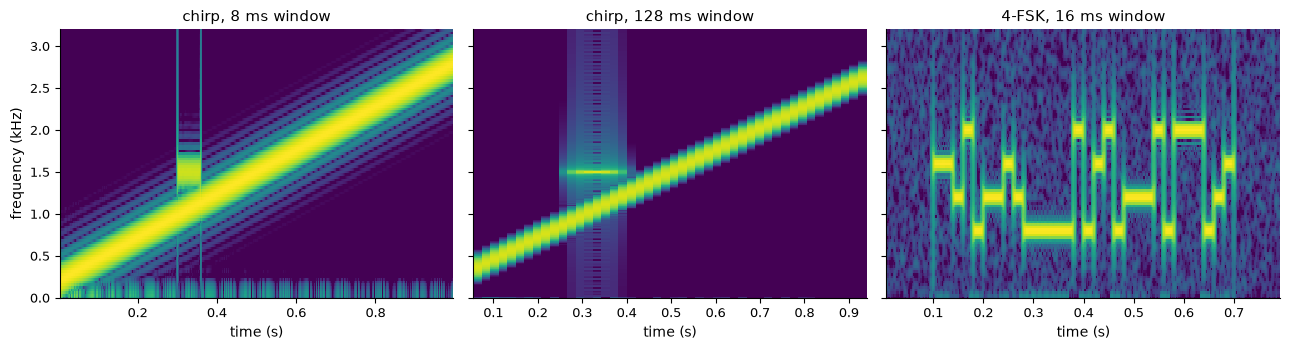

,
window duration,16.0 ms
frequency resolution ≈ 1/T (Hann ≈ 2/T main lobe),"62 Hz bin, 125 Hz main lobe"
FSK tone spacing / symbol time,400 Hz / 20 ms


In [11]:
def stft_demo(nper=128, overlap=0.85):
    fs = 8000; t = np.arange(0, 1.0, 1 / fs)
    chirp = np.cos(2 * np.pi * (200 * t + 0.5 * 2600 * t ** 2)) + 0.6 * np.cos(2 * np.pi * 1500 * t) * (t > 0.3) * (t < 0.36)
    r = np.random.default_rng(5)
    syms = r.integers(0, 4, 40); Ts = 0.02
    fsk_f = np.repeat(np.array([800, 1200, 1600, 2000])[syms], int(Ts * fs)); tf = np.arange(len(fsk_f)) / fs
    fsk = np.cos(2 * np.pi * np.cumsum(fsk_f) / fs) * (tf > 0.1) * (tf < 0.7) + 0.02 * r.standard_normal(len(fsk_f))
    fig, ax = lk.fig((13, 3.6), 1, 3, sharey=True)
    for a, sig, npr, ttl in [(ax[0], chirp, 64, "chirp, 8 ms window"), (ax[1], chirp, 1024, "chirp, 128 ms window"), (ax[2], fsk, nper, f"4-FSK, {1000 * nper / fs:.0f} ms window")]:
        ff, tt, S = sps.spectrogram(sig, fs, window="hann", nperseg=npr, noverlap=int(npr * overlap), nfft=max(npr, 256))
        Sd = lk.db(S + 1e-12); Sd -= Sd.max()
        a.pcolormesh(tt, ff / 1e3, Sd, vmin=-60, vmax=0, cmap="viridis", shading="auto", rasterized=True); a.grid(False)
        a.set_title(ttl); a.set_xlabel("time (s)")
    ax[0].set_ylabel("frequency (kHz)"); ax[0].set_ylim(0, 3.2)
    lk.show(fig)
    lk.table([["window duration", f"{1000 * nper / fs:.1f} ms"], ["frequency resolution ≈ 1/T (Hann ≈ 2/T main lobe)", f"{fs / nper:.0f} Hz bin, {2 * fs / nper:.0f} Hz main lobe"],
              ["FSK tone spacing / symbol time", "400 Hz / 20 ms"]], ["", ""])

lk.interact(stft_demo, nper=lk.choice([32, 64, 128, 256, 512], 128, "FSK window (samples at 8 kHz)"), overlap=lk.slider(0.85, 0, 0.95, 0.05, "overlap"))

**What you should see.** The 8 ms window shows the burst's start and end sharply but draws the chirp as a fat line; the 128 ms window
draws a thin chirp but smears the 60 ms burst across time. For the FSK burst, 16 ms (128 samples) is a good compromise: each 20 ms
symbol is visible and the 400 Hz tone spacing resolved; at 4 ms the tones blur, at 64 ms the symbols do.

## 5. Five bandwidths of one signal

"Bandwidth" has at least five meanings: the 3 dB width, the noise-equivalent width $B_N$, the null-to-null width, the 99% occupied
bandwidth (a regulatory favourite) and the x-dB (e.g. −26 dB) width. Chapter 2's worked example compares rectangular BPSK and RRC QPSK
($\beta = 0.22$, mild PA regrowth) at 1 Msymbol/s: equal noise bandwidths (about 1 MHz), but 99% occupied bandwidths of 20.5 MHz and
1.08 MHz.

### Interactive: roll-off and PA compression

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

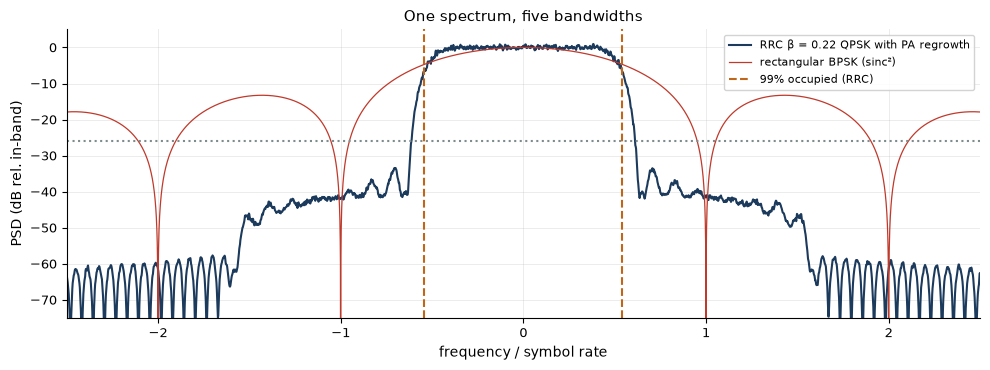

definition (× symbol rate),rectangular BPSK,RRC QPSK β = 0.22
3 dB,0.88,1.00
noise-equivalent,1.00,1.00
null-to-null,2.00,(no nulls)
99% occupied,20.33,1.08
−26 dB,11.30,1.22


In [13]:
def bw_metrics(f, S, ref):
    df = f[1] - f[0]
    above = np.flatnonzero(S >= ref / 2); a26 = np.flatnonzero(S >= ref * 10 ** -2.6)
    cum = np.cumsum(S) / S.sum()
    lo, hi = f[np.searchsorted(cum, 0.005)], f[np.searchsorted(cum, 0.995)]
    return dict(b3=(above.max() - above.min() + 1) * df, b26=(a26.max() - a26.min() + 1) * df, obw=hi - lo, bn=S.sum() * df / ref, lo=lo, hi=hi)

def bw_demo(beta=0.22, compression=0.035):
    r = np.random.default_rng(7)
    sp_ = 8
    s = cl.shape(cl.get_constellation("qpsk").modulate(cl.random_bits(2 * 40000, r)), cl.rrc_taps(beta, sp_, 16), sp_)
    s /= np.sqrt(np.mean(np.abs(s) ** 2))
    y = s - compression * s * np.abs(s) ** 2
    f, S = sps.welch(y, fs=sp_, nperseg=4096, return_onesided=False, window="blackmanharris", detrend=False)
    f = np.fft.fftshift(f); S = np.fft.fftshift(S)
    m = bw_metrics(f, S, np.median(S[np.abs(f) < 0.3]))
    fr = np.linspace(-1000, 1000, 2_000_001); Sr = np.sinc(fr) ** 2         # rectangular BPSK, analytic (wide: its tails hold 1%)
    mr = bw_metrics(fr, Sr, 1.0)
    fig, ax = lk.fig((10, 3.8))
    ax.plot(f, lk.db(S / np.median(S[np.abs(f) < 0.3])), color=lk.NAVY, label=f"RRC β = {beta:g} QPSK with PA regrowth")
    ax.plot(fr[np.abs(fr) < 2.5], lk.db(Sr[np.abs(fr) < 2.5] + 1e-12), color=lk.RED, lw=0.9, label="rectangular BPSK (sinc²)")
    ax.axvline(m["lo"], color=lk.ORANGE, ls="--"); ax.axvline(m["hi"], color=lk.ORANGE, ls="--", label="99% occupied (RRC)")
    ax.axhline(-26, color=lk.GRAY, ls=":"); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-75, 5); ax.legend(fontsize=8)
    ax.set_xlabel("frequency / symbol rate"); ax.set_ylabel("PSD (dB rel. in-band)"); ax.set_title("One spectrum, five bandwidths")
    lk.show(fig)
    lk.table([["3 dB", mr["b3"], m["b3"]], ["noise-equivalent", mr["bn"], m["bn"]], ["null-to-null", 2.0, "(no nulls)"],
              ["99% occupied", mr["obw"], m["obw"]], ["−26 dB", mr["b26"], m["b26"]]],
             ["definition (× symbol rate)", "rectangular BPSK", f"RRC QPSK β = {beta:g}"], fmt=".2f")

lk.interact(bw_demo, beta=lk.slider(0.22, 0.05, 1.0, 0.01, "RRC roll-off β"), compression=lk.slider(0.035, 0, 0.12, 0.005, "PA cubic compression"))

**What you should see.** The table reproduces Chapter 2: rectangular BPSK 0.89, 1.00, 2.00, about 20.5 and 11.3 symbol rates; RRC QPSK
about 1.00, 0.99, none, 1.08 and 1.22. Same noise bandwidth, twenty times different occupied bandwidth. Raise the PA compression: the
regrowth skirts lift the −26 dB and 99% widths while the 3 dB and noise bandwidths barely move. Every bandwidth in a specification should
name its definition.

### Try it yourself 5.1
What is the null-to-null bandwidth (MHz) of 5 Msymbol/s BPSK with rectangular pulses?

In [15]:
answer_5_1 = None
lk.check("5.1 null-to-null bandwidth (MHz)", answer_5_1, 10.0, atol=0.01)

[TODO] 5.1 null-to-null bandwidth (MHz): not attempted yet: replace the None with your answer

## 6. Two-tone testing and IP3

Drive an amplifier $y = a_1x + a_2x^2 + a_3x^3$ with two equal tones at $f_1$, $f_2$. The cubic term creates **third-order intermodulation**
at $2f_1 - f_2$ and $2f_2 - f_1$, right next to the tones where no filter can remove them. Their level rises 3 dB per dB of input, the
tones' only 1 dB per dB, so the extrapolated lines meet at the **third-order intercept**: $\mathrm{IIP3} = P_{in} + \Delta/2$, where $\Delta$ is
the tone-to-IM3 ratio. Chapter 2's example: −20 dBm tones, IM3 70 dB below them: IIP3 = +15 dBm, OIP3 = +30 dBm with 15 dB of gain; two
−40 dBm interferers then make an IM3 product at −150 dBm, harmless, but at −25 dBm it is −105 dBm, well above a 200 kHz channel's noise.

### Interactive: amplifier coefficients and drive

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

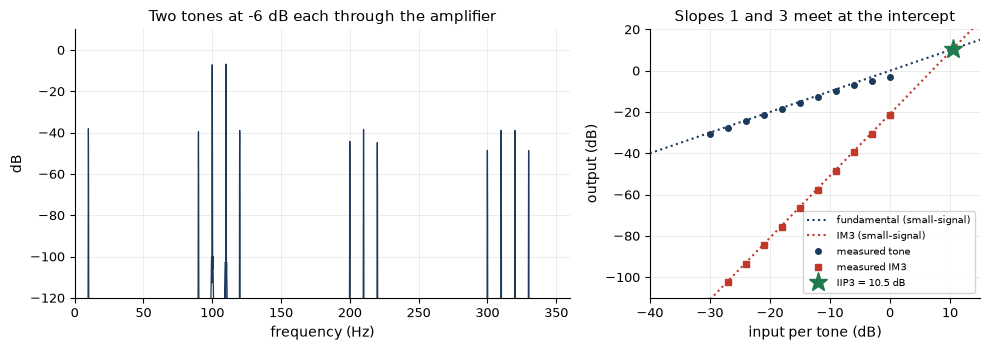

,
tone − IM3 at this drive,32.4 dB
IIP3 = P_in + Δ/2,10.2 dB (theory 10.5)
"Chapter 2: −20 dBm tones, Δ = 70 dB","IIP3 = +15 dBm, OIP3 = +30 dBm"
… IM3 from two −40 dBm interferers,-150 dBm
… from two −25 dBm interferers,-105 dBm


In [17]:
def twotone_demo(drive_db=-6.0, a2=0.05, a3=-0.12, spacing=10.0):
    fs = 1000.0; N = 2 ** 14; n = np.arange(N); f1 = 100.0; f2 = f1 + spacing
    A = 10 ** (drive_db / 20)
    x = A * (np.cos(2 * np.pi * f1 * n / fs) + np.cos(2 * np.pi * f2 * n / fs))
    y = x + a2 * x ** 2 + a3 * x ** 3
    w = sps.windows.blackmanharris(N)
    Y = np.abs(np.fft.rfft(y * w)) / np.sum(w) * 2
    fr = np.fft.rfftfreq(N, 1 / fs)
    fig, ax = lk.fig("row2", 1, 2, gridspec_kw=dict(width_ratios=[1.5, 1]))
    ax[0].plot(fr, lk.db(Y + 1e-9, power=False), color=lk.NAVY, lw=0.9); ax[0].set_xlim(0, 360); ax[0].set_ylim(-120, 10)
    ax[0].set_xlabel("frequency (Hz)"); ax[0].set_ylabel("dB"); ax[0].set_title(f"Two tones at {drive_db:g} dB each through the amplifier")
    k = lambda f_: np.argmin(np.abs(fr - f_))
    tone = lk.db(Y[k(f1)], power=False); im3 = lk.db(Y[k(2 * f1 - f2)], power=False)
    pin = np.linspace(-40, 15, 200)
    Ain = 10 ** (pin / 20)
    ax[1].plot(pin, lk.db(Ain, power=False), ":", color=lk.NAVY, label="fundamental (small-signal)")
    ax[1].plot(pin, lk.db(0.75 * abs(a3) * Ain ** 3 + 1e-12, power=False), ":", color=lk.RED, label="IM3 (small-signal)")
    meas_p = np.arange(-30, 1, 3.0); mt, mi = [], []
    for p_ in meas_p:
        Ap = 10 ** (p_ / 20)
        xx = Ap * (np.cos(2 * np.pi * f1 * n / fs) + np.cos(2 * np.pi * f2 * n / fs))
        YY = np.abs(np.fft.rfft((xx + a2 * xx ** 2 + a3 * xx ** 3) * w)) / np.sum(w) * 2
        mt.append(lk.db(YY[k(f1)], power=False)); mi.append(lk.db(YY[k(2 * f1 - f2)], power=False))
    ax[1].plot(meas_p, mt, "o", color=lk.NAVY, ms=4, label="measured tone"); ax[1].plot(meas_p, mi, "s", color=lk.RED, ms=4, label="measured IM3")
    iip3 = lk.db(np.sqrt(4 / 3 / abs(a3)), power=False)
    ax[1].plot(iip3, iip3, "*", ms=14, color=lk.GREEN, label=f"IIP3 = {iip3:.1f} dB")
    ax[1].set_xlim(-40, 15); ax[1].set_ylim(-110, 20); ax[1].set_xlabel("input per tone (dB)"); ax[1].set_ylabel("output (dB)"); ax[1].legend(fontsize=7.5)
    ax[1].set_title("Slopes 1 and 3 meet at the intercept")
    lk.show(fig)
    delta = tone - im3
    lk.table([["tone − IM3 at this drive", f"{delta:.1f} dB"], ["IIP3 = P_in + Δ/2", f"{drive_db + delta / 2:.1f} dB (theory {iip3:.1f})"],
              ["Chapter 2: −20 dBm tones, Δ = 70 dB", f"IIP3 = {-20 + 35:+.0f} dBm, OIP3 = {-20 + 35 + 15:+.0f} dBm"],
              ["… IM3 from two −40 dBm interferers", f"{-40 - 2 * (15 + 40):.0f} dBm"], ["… from two −25 dBm interferers", f"{-25 - 2 * (15 + 25):.0f} dBm"]], ["", ""])

lk.interact(twotone_demo, drive_db=lk.slider(-6, -30, 6, 1, "input per tone (dB)"), a2=lk.slider(0.05, 0, 0.3, 0.01, "a2"),
            a3=lk.slider(-0.12, -0.5, -0.01, 0.01, "a3"), spacing=lk.slider(10, 2, 40, 1, "tone spacing (Hz)"))

**What you should see.** The spectrum shows the two tones, IM3 products one spacing away on either side, second-order products near DC
and at $2f$, and third-order harmonics. Measured points follow slopes 1 and 3 at low drive and bend as the amplifier compresses; the
extrapolated lines meet at IIP3 = $10\log_{10}(4/3|a_3|)$ ≈ 10.5 dB for $a_3 = -0.12$, and the estimate $P_{in} + \Delta/2$ from a single
measurement agrees as long as the drive is well below compression. The chapter's numbers: +15 dBm IIP3, +30 dBm OIP3, IM3 at −150 and
−105 dBm.

### Try it yourself 6.1
An amplifier shows IM3 products 50 dB below two −10 dBm tones. What is its IIP3 (dBm)?

In [19]:
answer_6_1 = None
lk.check("6.1 IIP3 (dBm)", answer_6_1, -10 + 25, atol=0.1)

[TODO] 6.1 IIP3 (dBm): not attempted yet: replace the None with your answer

## Key takeaways
* The window sets leakage and scalloping; zero padding interpolates but never resolves; resolution is 1/(observation time).
* $\sigma_t\sigma_f \ge 1/4\pi$; the Gaussian achieves it.
* Phase delay moves the carrier, group delay the envelope; frequency-dependent group delay disperses pulses.
* The spectrogram trades time against frequency resolution through the window length.
* Bandwidth has many definitions; the noise-equivalent one sets SNR, the occupied one sets regulation.
* IM3 grows 3 dB per dB; IIP3 = P_in + Δ/2 summarises an amplifier's linearity.

## Going further (hardware: USRP B200 / GNU Radio)
* Capture an FM broadcast band with `gnuradio/gr01_spectrum_iq_capture.py`, then re-analyse the capture with each window and FFT length of
  Section 1, and with the spectrogram of Section 4 (the RDS subcarrier at 57 kHz is a good target).
* Drive the B200's receiver with two tones from a second radio (through a combiner and attenuators) and measure its IIP3 at several gain
  settings: linearity falls as RF gain rises.

## Exercises
1. **(Warm-up)** Show that zero padding a 256-point DFT to 2048 points interpolates the same DTFT, and compute the main-lobe width of Hann.
2. **(Core)** Use a flat-top window to measure the amplitude of a tone at a random frequency to ±0.01 dB, and compare with Hann.
3. **(Core)** Compute the 99% occupied bandwidth of GMSK with BT = 0.3 (Lab 21) and compare with RRC QPSK at the same bit rate.
4. **(Stretch)** Add a fifth-order term to Section 6 and show that the IM3 slope departs from 3 near compression.

In [21]:
lk.summary()

[good] Lab 35 finished in 1.9 s. Self-checks: 0 passed, 0 failed, 3 still to do.